Трансформер для классификации изображений

Подготовка данных. Импорт zip архива.

In [ ]:
import os
import zipfile
import requests

def unzip_to_colab(zip_file_path, extract_path=None, delete_zip=False):
    """
    Unzips a zip archive in Google Colab.

    Args:
        zip_file_path (str): Path to the zip file (local in Colab or URL).
        extract_path (str, optional): Path to extract the archive to.
                                      If None, extracts to the current working directory.
                                      Defaults to None.
        delete_zip (bool, optional):  Delete the zip file after successful extraction.
                                         Defaults to False.
    """

    try:
        # 1. Check if the file exists
        if not os.path.exists(zip_file_path):
            print(f"Error: File '{zip_file_path}' not found.")
            return

        # 2. Determine the extraction path
        if extract_path is None:
            extract_path = os.getcwd()  # Current working directory
        else:
            # Create the directory if it doesn't exist
            os.makedirs(extract_path, exist_ok=True)


        # 3. Unzip the archive
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

        print(f"Zip archive '{zip_file_path}' successfully extracted to '{extract_path}'.")

        # 4. Delete the zip file (if specified)
        if delete_zip:
            try:
                os.remove(zip_file_path)
                print(f"Zip file '{zip_file_path}' deleted.")
            except OSError as e:
                print(f"Error deleting zip file: {e}")


    except zipfile.BadZipFile as e:
        print(f"Error: File '{zip_file_path}' is not a valid zip archive. Error: {e}")
    except FileNotFoundError as e:
        print(f"Error: File '{zip_file_path}' not found. Error: {e}")
    except Exception as e:
        print(f"An error occurred during extraction: {e}")


def download_and_save(url, save_path):
    """
    Downloads a file from a URL and saves it.
    """
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()  # Check that the request was successful

        with open(save_path, 'wb') as file:
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)
        print(f"File successfully downloaded and saved to: {save_path}")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading file from '{url}': {e}")
        return False  # Indicate failure
    except Exception as e:
        print(f"An error occurred while downloading and saving the file: {e}")
        return False  # Indicate failure
    return True # Indicate success


# Optional: Check if the files were extracted successfully
# You can list the contents of the extraction directory to confirm.
# !ls "/content/sample_data" # Uncomment this line to list files in the directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install --upgrade tensorflow
!pip install --upgrade keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.1 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0


In [ ]:
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model

from tensorflow.keras.preprocessing import image
import pandas as pd

In [ ]:
model3 = load_model('/content/sample_data/keras_model.h5')

TypeError: Error when deserializing class 'DepthwiseConv2D' using config={'name': 'expanded_conv_depthwise', 'trainable': True, 'dtype': 'float32', 'kernel_size': [3, 3], 'strides': [1, 1], 'padding': 'same', 'data_format': 'channels_last', 'dilation_rate': [1, 1], 'groups': 1, 'activation': 'linear', 'use_bias': False, 'bias_initializer': {'class_name': 'Zeros', 'config': {}}, 'bias_regularizer': None, 'activity_regularizer': None, 'bias_constraint': None, 'depth_multiplier': 1, 'depthwise_initializer': {'class_name': 'VarianceScaling', 'config': {'scale': 1, 'mode': 'fan_avg', 'distribution': 'uniform', 'seed': None}}, 'depthwise_regularizer': None, 'depthwise_constraint': None}.

Exception encountered: Unrecognized keyword arguments passed to DepthwiseConv2D: {'groups': 1}

In [ ]:
# Example usage
zip_file_path = '/content/dataset.zip'
extract_path = '/content/sample_data'

unzip_to_colab(zip_file_path, extract_path)


Zip archive '/content/dataset.zip' successfully extracted to '/content/sample_data'.


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, LayerNormalization, Embedding, Input, Dropout, Conv2D, Reshape, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10

# --------------------  Параметры --------------------
IMAGE_SIZE = 32
PATCH_SIZE = 4
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
EMBED_DIM = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_LAYERS = 6
NUM_CLASSES = 2
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 0.001

# --------------------  Подготовка данных --------------------
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = tf.keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=NUM_CLASSES)

# --------------------  Patch Extraction Layer --------------------
class PatchExtraction(Layer):
    def __init__(self, patch_size, **kwargs):
        super(PatchExtraction, self).__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

# --------------------  Positional Embedding Layer --------------------
class PositionalEmbedding(Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super(PositionalEmbedding, self).__init__(**kwargs)
        self.pos_emb = self.add_weight(
            name="pos_embedding", shape=(1, num_patches, embed_dim)
        )

    def call(self, patches):
        return patches + self.pos_emb

# --------------------  Transformer Encoder --------------------
class TransformerEncoder(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])

        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# --------------------  Classification Head --------------------
class ClassificationHead(Layer):
    def __init__(self, num_classes, rate=0.1, **kwargs):
        super(ClassificationHead, self).__init__(**kwargs)
        self.global_pool = tf.keras.layers.GlobalAveragePooling1D()
        self.dropout = Dropout(rate)
        self.classifier = Dense(num_classes, activation="softmax")

    def call(self, inputs, training):
        x = self.global_pool(inputs)
        x = self.dropout(x, training=training)
        return self.classifier(x)

# --------------------  ViT Model --------------------
def create_vit_model(image_size, patch_size, num_patches, embed_dim, num_heads, ff_dim, num_layers, num_classes):
    inputs = Input(shape=(image_size, image_size, 3))
    x = PatchExtraction(patch_size)(inputs)
    x = Dense(embed_dim)(x)  # Linear projection
    x = PositionalEmbedding(num_patches, embed_dim)(x)
    x = Dropout(0.1)(x)  # Dropout after positional embeddings
    for _ in range(num_layers):
        x = TransformerEncoder(embed_dim, num_heads, ff_dim)(x)
    outputs = ClassificationHead(num_classes)(x)
    return Model(inputs=inputs, outputs=outputs)

vit_model = create_vit_model(IMAGE_SIZE, PATCH_SIZE, NUM_PATCHES, EMBED_DIM, NUM_HEADS, FF_DIM, NUM_LAYERS, NUM_CLASSES)

# --------------------  Компиляция --------------------
vit_model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

# --------------------  Обучение --------------------
print("Обучение ViT модели...")
history = vit_model.fit(x_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS, validation_data=(x_test, y_test))

# --------------------  Оценка --------------------
loss, accuracy = vit_model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy: {accuracy}")

Классификация/кластеризация


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import wasserstein_distance  # Для сравнения распределений
import tensorflow as tf
from tensorflow.keras import layers, models, losses
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
import os  #Для операций с файловой системой
import random #Для воспроизводимости


In [ ]:
# -------------------- Параметры --------------------
img_width = 400
img_height = 400
channels = 1  # 1 для черно-белых изображений
latent_dim = 32  # Размерность скрытого пространства (эмбеддинга)
batch_size = 16
epochs = 10
learning_rate = 0.001

# Пути к данным (замените своими путями!)
good_data_dir = '/content/sample_data/all'  # Папка с изображениями нормальных деталей
bad_data_dir = '/content/sample_data/all'  # Папка с изображениями бракованных деталей
# -------------------- Функции загрузки данных --------------------

def load_images(data_dir):
    """Загружает изображения из указанной директории и нормализует их."""
    image_files = [f for f in os.listdir(data_dir) if f.endswith('.jpg')]  # или '.jpg', '.jpeg'
    images = []
    for file in image_files:
        img_path = os.path.join(data_dir, file)
        img = tf.keras.utils.load_img(img_path, color_mode='grayscale', target_size=(img_width, img_height))
        img_array = tf.keras.utils.img_to_array(img)
        img_array = img_array.astype('float32') / 255.0  # Нормализация
        images.append(img_array)
    return np.array(images)

def create_dataset(good_data_dir, bad_data_dir, test_size=0.2, random_state=42):
    """Создает обучающий и тестовый наборы данных, разделяя хорошие и плохие изображения."""
    good_images = load_images(good_data_dir)
    bad_images = load_images(bad_data_dir)

    # Создаем метки: 0 для хороших, 1 для плохих
    good_labels = np.zeros(len(good_images))
    bad_labels = np.ones(len(bad_images))

    # Объединяем данные и метки
    all_images = np.concatenate([good_images, bad_images], axis=0)
    all_labels = np.concatenate([good_labels, bad_labels], axis=0)

    # Разделяем на обучающий и тестовый наборы
    train_images, test_images, train_labels, test_labels = train_test_split(
        all_images, all_labels, test_size=test_size, random_state=random_state
    )

    return train_images, test_images, train_labels, test_labels


In [ ]:

# --------------------  Модель автоэнкодера --------------------

def build_autoencoder(latent_dim, img_width, img_height, channels, learning_rate):
    """Строит модель автоэнкодера."""

    # Энкодер
    encoder_inputs = tf.keras.Input(shape=(img_width, img_height, channels))
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Flatten()(x)
    encoder_outputs = layers.Dense(latent_dim, activation='relu')(x)  # Скрытое пространство
    encoder = tf.keras.Model(encoder_inputs, encoder_outputs, name="encoder")

    # Декодер
    latent_inputs = tf.keras.Input(shape=(latent_dim,))
    x = layers.Dense(img_width // 4 * img_height // 4 * 64, activation='relu')(latent_inputs)
    x = layers.Reshape((img_width // 4, img_height // 4, 64))(x)
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)
    decoder_outputs = layers.Conv2D(channels, (3, 3), activation='sigmoid', padding='same')(x)  # sigmoid для [0, 1]
    decoder = tf.keras.Model(latent_inputs, decoder_outputs, name="decoder")

    # Автоэнкодер (соединяем энкодер и декодер)
    autoencoder_input = tf.keras.Input(shape=(img_width, img_height, channels))
    encoded = encoder(autoencoder_input)
    decoded = decoder(encoded)
    autoencoder = tf.keras.Model(autoencoder_input, decoded, name="autoencoder")

    # Компиляция
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    autoencoder.compile(optimizer=optimizer, loss='mse')  # MSE - подходит для изображений
    return encoder, decoder, autoencoder


In [ ]:
# -------------------- Обучение --------------------

def train_autoencoder(autoencoder, train_data, val_data, epochs, batch_size, patience=10):
    """Обучает автоэнкодер с ранней остановкой."""
    early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    history = autoencoder.fit(train_data, train_data,
                              epochs=epochs,
                              batch_size=batch_size,
                              shuffle=True,
                              validation_data=(val_data, val_data),
                              callbacks=[early_stopping])  # Изображения восстанавливаются сами в себя
    return history

# -------------------- Функция для визуализации результатов обучения --------------------
def visualize_training_results(history):
    """Визуализирует графики потерь во время обучения."""
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Потери во время обучения')
    plt.xlabel('Эпоха')
    plt.ylabel('Потеря')
    plt.legend()

    plt.tight_layout()
    plt.show()



Обучение автоэнкодера для нормальных деталей...
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 411s 12s/step - loss: 0.0373 - val_loss: 0.0214
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 382s 12s/step - loss: 0.0154 - val_loss: 0.0132
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 385s 12s/step - loss: 0.0120 - val_loss: 0.0102
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 442s 12s/step - loss: 0.0095 - val_loss: 0.0093
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 440s 12s/step - loss: 0.0086 - val_loss: 0.0073
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 446s 12s/step - loss: 0.0073 - val_loss: 0.0068
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 366s 11s/step - loss: 0.0066 - val_loss: 0.0060
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 379s 11s/step - loss: 0.0056 - val_loss: 0.0053
Epoch 9/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 401s 12s/step - loss: 0.0050 - val_loss: 0.0047
Epoch 10/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 383s 12s/step - loss: 0.0046 - val_loss: 0.0045


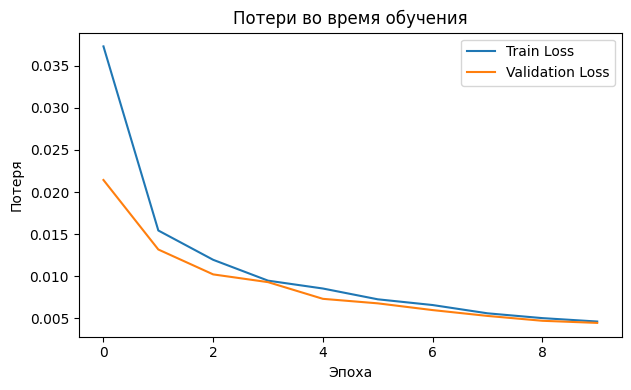

Обучение автоэнкодера для бракованных деталей...
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 377s 11s/step - loss: 0.0423 - val_loss: 0.0167
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 411s 12s/step - loss: 0.0149 - val_loss: 0.0128
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 430s 12s/step - loss: 0.0121 - val_loss: 0.0096
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 424s 11s/step - loss: 0.0099 - val_loss: 0.0090
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 385s 11s/step - loss: 0.0093 - val_loss: 0.0082
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 402s 12s/step - loss: 0.0078 - val_loss: 0.0069
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 421s 11s/step - loss: 0.0072 - val_loss: 0.0068
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 402s 12s/step - loss: 0.0067 - val_loss: 0.0060
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 401s 12s/step - loss: 0.0061 - val_loss: 0.0058
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 436s 12s/step - loss: 0.0059 - val_loss: 0.0057


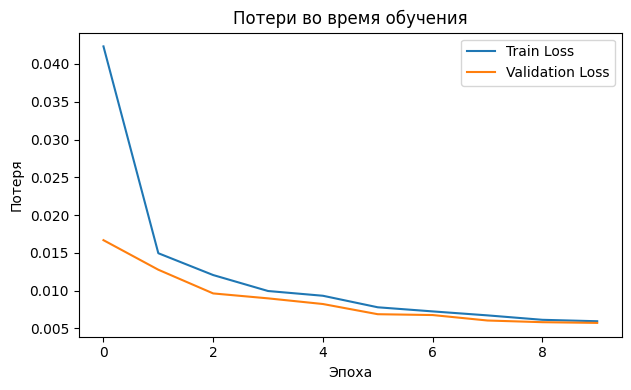

In [16]:
# -------------------- Основной скрипт --------------------

if __name__ == '__main__':
    # 1. Загрузка и подготовка данных
    train_images, test_images, train_labels, test_labels = create_dataset(good_data_dir, bad_data_dir)
    X_train_good = train_images[train_labels == 0]
    X_train_bad = train_images[train_labels == 1]
    X_test_good = test_images[test_labels == 0]
    X_test_bad = test_images[test_labels == 1]

    # Разделение обучающих данных на обучающую и проверочную выборки для каждой категории
    X_train_good, X_val_good = train_test_split(X_train_good, test_size=0.2, random_state=42)
    X_train_bad, X_val_bad = train_test_split(X_train_bad, test_size=0.2, random_state=42)

    # 2. Создание и обучение автоэнкодеров
    encoder_good, decoder_good, autoencoder_good = build_autoencoder(latent_dim, img_width, img_height, channels, learning_rate)
    encoder_bad, decoder_bad, autoencoder_bad = build_autoencoder(latent_dim, img_width, img_height, channels, learning_rate)

    print("Обучение автоэнкодера для нормальных деталей...")
    history_good = train_autoencoder(autoencoder_good, X_train_good, X_val_good, epochs, batch_size)
    visualize_training_results(history_good)

    print("Обучение автоэнкодера для бракованных деталей...")
    history_bad = train_autoencoder(autoencoder_bad, X_train_bad, X_val_bad, epochs, batch_size)
    visualize_training_results(history_bad)



17/17 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
Silhouette Score: 0.511432945728302
Слишком большая размерность скрытого пространства для визуализации кластеров.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107m

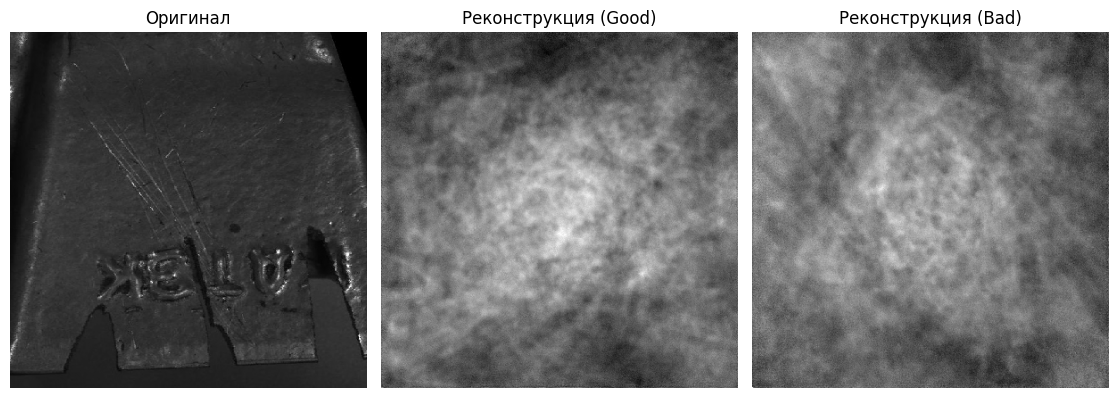

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


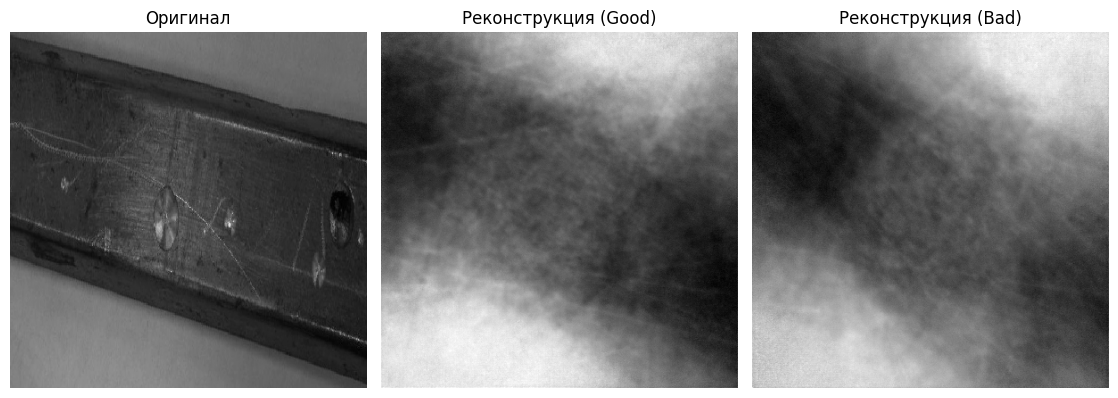

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


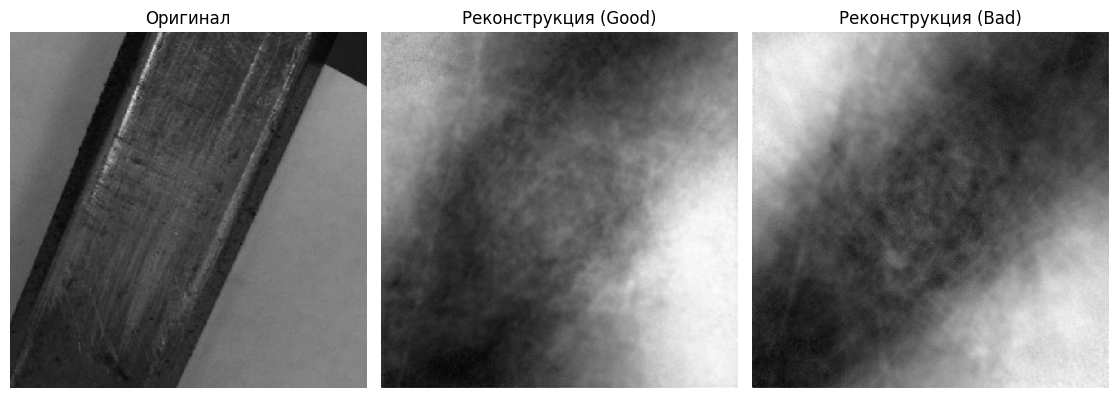

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


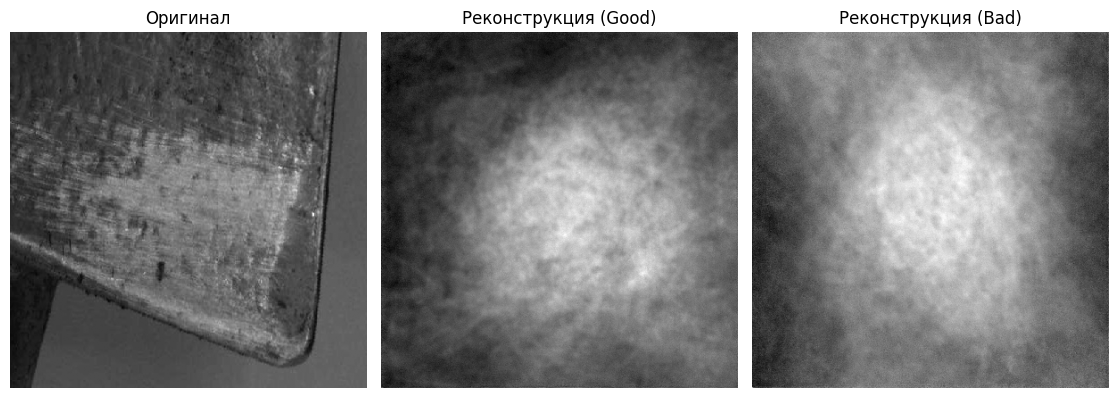

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step


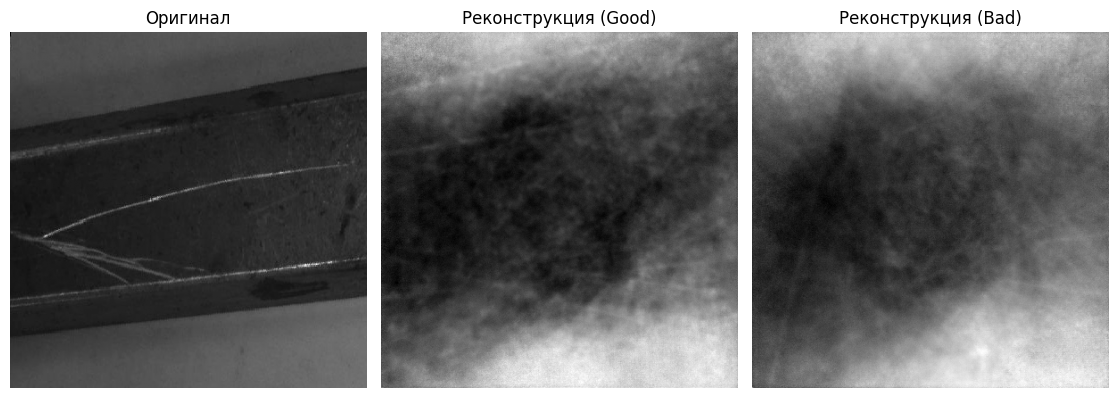

In [17]:

    # 3. Получение эмбеддингов
    embeddings_good_train = encoder_good.predict(X_train_good)
    embeddings_bad_train = encoder_bad.predict(X_train_bad)
    embeddings_good_test = encoder_good.predict(X_test_good)
    embeddings_bad_test = encoder_bad.predict(X_test_bad)

    # Объединение эмбеддингов для кластеризации
    all_embeddings = np.concatenate([embeddings_good_train, embeddings_bad_train, embeddings_good_test, embeddings_bad_test])

    # 4. Кластеризация эмбеддингов
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)  # Важно указать n_init
    cluster_labels = kmeans.fit_predict(all_embeddings)

    # Оценка качества кластеризации (Silhouette Score)
    silhouette_avg = silhouette_score(all_embeddings, cluster_labels)
    print(f"Silhouette Score: {silhouette_avg}")

    # Визуализация кластеризации (если latent_dim <= 2)
    if latent_dim <= 2:
        plt.figure(figsize=(8, 6))
        plt.scatter(all_embeddings[:, 0], all_embeddings[:, 1], c=cluster_labels, cmap='viridis')
        plt.title('Кластеризация эмбеддингов')
        plt.xlabel('Latent Dim 1')
        plt.ylabel('Latent Dim 2')
        plt.colorbar(label='Кластер')
        plt.show()
    else:
        print("Слишком большая размерность скрытого пространства для визуализации кластеров.")

    # 5. Классификация новых изображений

    def classify_image(image, encoder_good, encoder_bad):
        """Классифицирует новое изображение, используя расстояние Вассерштейна."""
        embedding_good = encoder_good.predict(np.expand_dims(image, axis=0))
        embedding_bad = encoder_bad.predict(np.expand_dims(image, axis=0))

        # Вычисляем расстояние Вассерштейна между эмбеддингами и средними эмбеддингами обучающих данных
        distance_good = wasserstein_distance(embedding_good.flatten(), np.mean(embeddings_good_train, axis=0).flatten())
        distance_bad = wasserstein_distance(embedding_bad.flatten(), np.mean(embeddings_bad_train, axis=0).flatten())

        if distance_good < distance_bad:
            return "Good", distance_good, distance_bad
        else:
            return "Bad", distance_good, distance_bad

    # 6. Оценка классификации на тестовых данных
    correct_predictions = 0
    total_predictions = len(test_images)

    for i in range(len(test_images)):
        image = test_images[i]
        true_label = "Good" if test_labels[i] == 0 else "Bad"
        predicted_label, dist_good, dist_bad = classify_image(image, encoder_good, encoder_bad)
        if predicted_label == true_label:
            correct_predictions += 1
        #print(f"Изображение {i+1}: Истинный класс: {true_label}, Предсказанный класс: {predicted_label}, Расстояние до Good: {dist_good:.4f}, Расстояние до Bad: {dist_bad:.4f}")

    accuracy = correct_predictions / total_predictions
    print(f"Точность классификации: {accuracy:.4f}")

    # 7. Визуализация результатов

    def visualize_results(image, encoder_good, encoder_bad, decoder_good, decoder_bad):
      """Визуализирует оригинальное изображение, его реконструкции и эмбеддинги."""
      plt.figure(figsize=(15, 5))

      # Оригинальное изображение
      plt.subplot(1, 4, 1)
      plt.imshow(image.squeeze(), cmap='gray')
      plt.title('Оригинал')
      plt.axis('off')

      # Реконструкция "хорошим" автоэнкодером
      reconstructed_good = decoder_good.predict(encoder_good.predict(np.expand_dims(image, axis=0)))
      plt.subplot(1, 4, 2)
      plt.imshow(reconstructed_good.squeeze(), cmap='gray')
      plt.title('Реконструкция (Good)')
      plt.axis('off')

      # Реконструкция "плохим" автоэнкодером
      reconstructed_bad = decoder_bad.predict(encoder_bad.predict(np.expand_dims(image, axis=0)))
      plt.subplot(1, 4, 3)
      plt.imshow(reconstructed_bad.squeeze(), cmap='gray')
      plt.title('Реконструкция (Bad)')
      plt.axis('off')

      # Эмбеддинги (только если размерность позволяет)
      if latent_dim <= 2:
          embedding_good = encoder_good.predict(np.expand_dims(image, axis=0))
          embedding_bad = encoder_bad.predict(np.expand_dims(image, axis=0))

          plt.subplot(1, 4, 4)
          plt.scatter(embedding_good[:, 0], embedding_good[:, 1], color='green', label='Good Embedding')
          plt.scatter(embedding_bad[:, 0], embedding_bad[:, 1], color='red', label='Bad Embedding')
          plt.title('Эмбеддинги')
          plt.xlabel('Latent Dim 1')
          plt.ylabel('Latent Dim 2')
          plt.legend()

      plt.tight_layout()
      plt.show()

    # Выводим несколько случайных изображений из тестового набора
    num_visualize = 5
    random_indices = random.sample(range(len(test_images)), num_visualize)  # Выбираем случайные индексы

    for i in random_indices:
        visualize_results(test_images[i], encoder_good, encoder_bad, decoder_good, decoder_bad)

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder # Для кодирования меток классов

def reduce_dimensionality(embeddings, n_components=2, method='PCA', explained_variance_threshold=None):
    if method == 'PCA':
        if explained_variance_threshold is not None:
            pca = PCA(n_components=None)
            pca.fit(embeddings)
            cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
            n_components = np.argmax(cumulative_variance >= explained_variance_threshold) + 1
            print(f"PCA: Using {n_components} components to explain {explained_variance_threshold*100}% variance")
            pca = PCA(n_components=n_components)
            reduced_embeddings = pca.fit_transform(embeddings)
        else:
            pca = PCA(n_components=n_components)
            reduced_embeddings = pca.fit_transform(embeddings)
            print(f"PCA: Using {n_components} components.")
    elif method == 'TSNE':
        tsne = TSNE(n_components=n_components, random_state=42)
        reduced_embeddings = tsne.fit_transform(embeddings)
        print(f"TSNE: Reduced to {n_components} components.")
    else:
        raise ValueError("Method must be 'PCA' or 'TSNE'")
    return reduced_embeddings

# Измененная функция визуализации
def visualize_clustering_with_labels(embeddings, labels, cluster_labels, method="PCA"):
    """
    Визуализирует кластеризацию с метками классов.

    Args:
        embeddings: Эмбеддинги с уменьшенной размерностью (n_samples, 2).
        labels: Истинные метки классов ("all" или "noall").
        cluster_labels: Метки кластеров, полученные после кластеризации.
        method: Метод снижения размерности для заголовка графика.
    """
    plt.figure(figsize=(8, 6))

    # Создаем словарь для соответствия метки кластера и цвета
    unique_labels = np.unique(labels)
    color_map = {'all': 'red', 'noall': 'green'}  # Задаем цвета для "all" и "noall"
    #Рисуем каждую точку, подкрашивая ее в зависимости от класса
    for label in unique_labels:
        indices = labels == label
        plt.scatter(embeddings[indices, 0], embeddings[indices, 1],
                    c=color_map[label], label=label) #Передаем цвет из color_map, исходя из label
    plt.title(f'Кластеризация эмбеддингов ({method})')
    plt.xlabel('Latent Dim 1')
    plt.ylabel('Latent Dim 2')
    plt.legend()
    plt.colorbar(label='Кластер')
    plt.show()


In [37]:
    labels_good_train = ["noall"] * len(embeddings_good_train)
    labels_bad_train = ["all"] * len(embeddings_bad_train)
    labels_good_test = ["noall"] * len(embeddings_good_test)
    labels_bad_test = ["all"] * len(embeddings_bad_test)
# Создаем метки для каждого набора эмбеддингов.  Важно, чтобы размер меток совпадал с размером эмбеддингов.
    labels_good_train = ["noall"] * len(embeddings_good_train)
    labels_bad_train = ["all"] * len(embeddings_bad_train)
    labels_good_test = ["noall"] * len(embeddings_good_test)
    labels_bad_test = ["all"] * len(embeddings_bad_test)

    # Объединяем эмбеддинги
    all_embeddings = np.concatenate([embeddings_good_train, embeddings_bad_train, embeddings_good_test, embeddings_bad_test])

    # Объединяем метки.  Важно, чтобы порядок меток соответствовал порядку эмбеддингов.
    all_labels = labels_good_train + labels_bad_train + labels_good_test + labels_bad_test

PCA: Using 2 components.


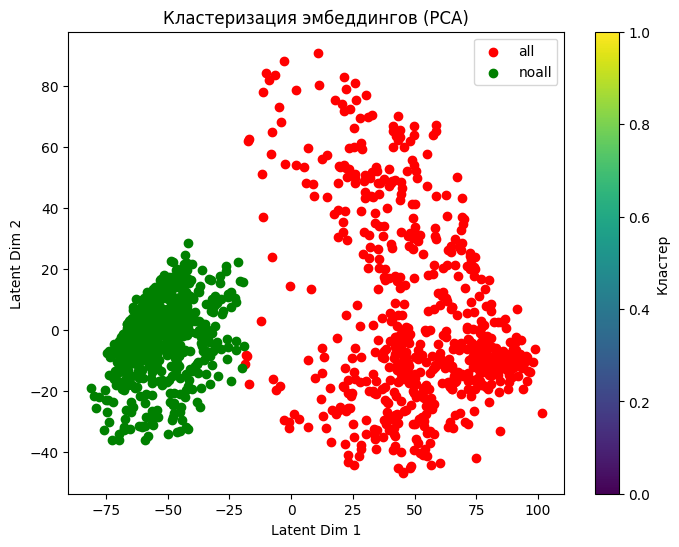

In [38]:
    reduced_embeddings = reduce_dimensionality(all_embeddings, n_components=2, method='PCA')

    #Визуализируем кластеризацию с правильными метками
    visualize_clustering_with_labels(reduced_embeddings, np.array(all_labels), cluster_labels, method="PCA")

In [34]:

if __name__ == '__main__':
    # Пример использования:
    num_samples = 100
    num_features = 32
    embeddings = np.concatenate([embeddings_good_train, embeddings_bad_train, embeddings_good_test, embeddings_bad_test]) #Объединяем эмбеддинги
    # Генерируем метки классов
    labels_good = ["noall"] * num_samples  # "noall" для хороших
    labels_bad = ["all"] * num_samples  # "all" для плохих
    labels = labels_good + labels_bad #Конкатенируем метки

    # Уменьшаем размерность эмбеддингов
    reduced_embeddings = reduce_dimensionality(embeddings, n_components=2, method='PCA')

    # Кластеризуем эмбеддинги
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
    # Визуализируем кластеризацию с метками классов
    visualize_clustering_with_labels(reduced_embeddings, np.array(labels), cluster_labels, method="PCA")

PCA: Using 2 components.


IndexError: boolean index did not match indexed array along axis 0; size of axis is 1388 but size of corresponding boolean axis is 200

<Figure size 800x600 with 0 Axes>

Silhouette Score: 0.6887584924697876


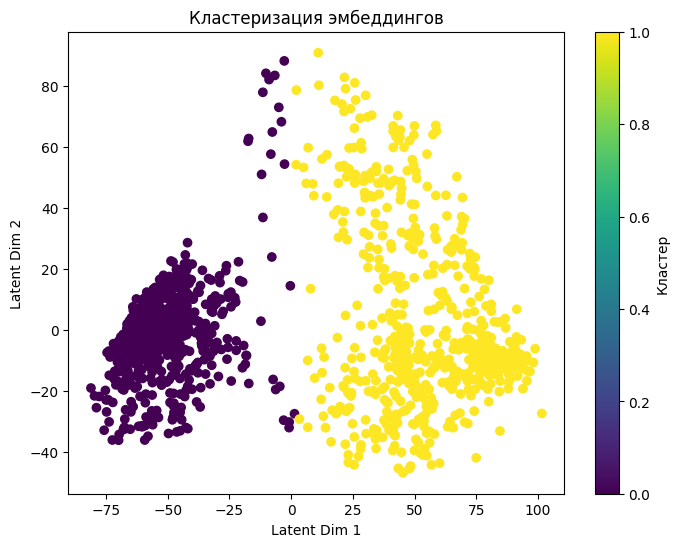

In [24]:
    # 4. Кластеризация эмбеддингов
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)  # Важно указать n_init
    cluster_labels = kmeans.fit_predict(reduced_embeddings_pca)

    # Оценка качества кластеризации (Silhouette Score)
    silhouette_avg = silhouette_score(reduced_embeddings_pca, cluster_labels)
    print(f"Silhouette Score: {silhouette_avg}")

    # Визуализация кластеризации (если latent_dim <= 2)
    plt.figure(figsize=(8, 6))
    plt.scatter(reduced_embeddings_pca[:, 0], reduced_embeddings_pca[:, 1], c=cluster_labels, cmap='viridis')
    plt.title('Кластеризация эмбеддингов')
    plt.xlabel('Latent Dim 1')
    plt.ylabel('Latent Dim 2')
    plt.colorbar(label='Кластер')
    plt.show()



In [26]:
# 5. Классификация новых изображений
    def classify_image(image, encoder_good, encoder_bad):
        """Классифицирует новое изображение, используя расстояние Вассерштейна."""
        embedding_good = encoder_good.predict(np.expand_dims(image, axis=0))
        embedding_bad = encoder_bad.predict(np.expand_dims(image, axis=0))

        # Вычисляем расстояние Вассерштейна между эмбеддингами и средними эмбеддингами обучающих данных
        distance_good = wasserstein_distance(embedding_good.flatten(), np.mean(embeddings_good_train, axis=0).flatten())
        distance_bad = wasserstein_distance(embedding_bad.flatten(), np.mean(embeddings_bad_train, axis=0).flatten())

        if distance_good < distance_bad:
            return "Good", distance_good, distance_bad
        else:
            return "Bad", distance_good, distance_bad


IndentationError: unexpected indent (ipython-input-3608172694.py, line 2)

In [21]:
    # 6. Оценка классификации на тестовых данных
    correct_predictions = 0
    total_predictions = len(test_images)

    for i in range(len(test_images)):
        image = test_images[i]
        true_label = "Good" if test_labels[i] == 0 else "Bad"
        predicted_label, dist_good, dist_bad = classify_image(image, encoder_good, encoder_bad)
        if predicted_label == true_label:
            correct_predictions += 1
        #print(f"Изображение {i+1}: Истинный класс: {true_label}, Предсказанный класс: {predicted_label}, Расстояние до Good: {dist_good:.4f}, Расстояние до Bad: {dist_bad:.4f}")

    accuracy = correct_predictions / total_predictions
    print(f"Точность классификации: {accuracy:.4f}")

Silhouette Score: 0.511432945728302
Слишком большая размерность скрытого пространства для визуализации кластеров.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98m

KeyboardInterrupt: 